In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from pathlib import Path
import tifffile as tiff

# Path to your microscopy TIFF stack (3D volume)
tif_path = Path("output/merged_from_annotations_classes.tif")

# If the default path doesn't exist, try auto-detection in dataset/
if not tif_path.exists():
    candidates = sorted(Path("dataset").glob("*.tif")) + sorted(Path("dataset").glob("*.tiff"))
    if len(candidates) == 0:
        raise FileNotFoundError(
            "No .tif/.tiff file found in dataset/. Set `tif_path` to your file path."
        )
    tif_path = candidates[0]
    print(f"Using detected TIFF file: {tif_path}")

volume = tiff.imread(tif_path)

# Ensure volume is (z, y, x) for slice-wise processing
if volume.ndim == 2:
    volume = volume[np.newaxis, ...]  # single image -> 1-slice volume
elif volume.ndim > 3:
    raise ValueError(f"Expected 2D/3D TIFF stack, got shape {volume.shape}")

print(f"Loaded TIFF: {tif_path}")
print(f"Volume shape (z, y, x): {volume.shape}")
print(f"dtype: {volume.dtype}")

Loaded TIFF: output/merged_from_annotations_classes.tif
Volume shape (z, y, x): (200, 512, 512)
dtype: uint8


In [3]:
# Keep only slices that contain information (not fully uniform)
v = volume.astype(np.float32)

slice_min = v.min(axis=(1, 2))
slice_max = v.max(axis=(1, 2))
slice_std = v.std(axis=(1, 2))

range_eps = 1e-6
std_eps = 1e-6

valid_indices = np.where(((slice_max - slice_min) > range_eps) & (slice_std > std_eps))[0]
volume_filtered = volume[valid_indices]  # original slice values are unchanged

print(f"Kept {len(valid_indices)}/{volume.shape[0]} informative slices")
print(f"Filtered volume shape: {volume_filtered.shape}")

Kept 72/200 informative slices
Filtered volume shape: (72, 512, 512)


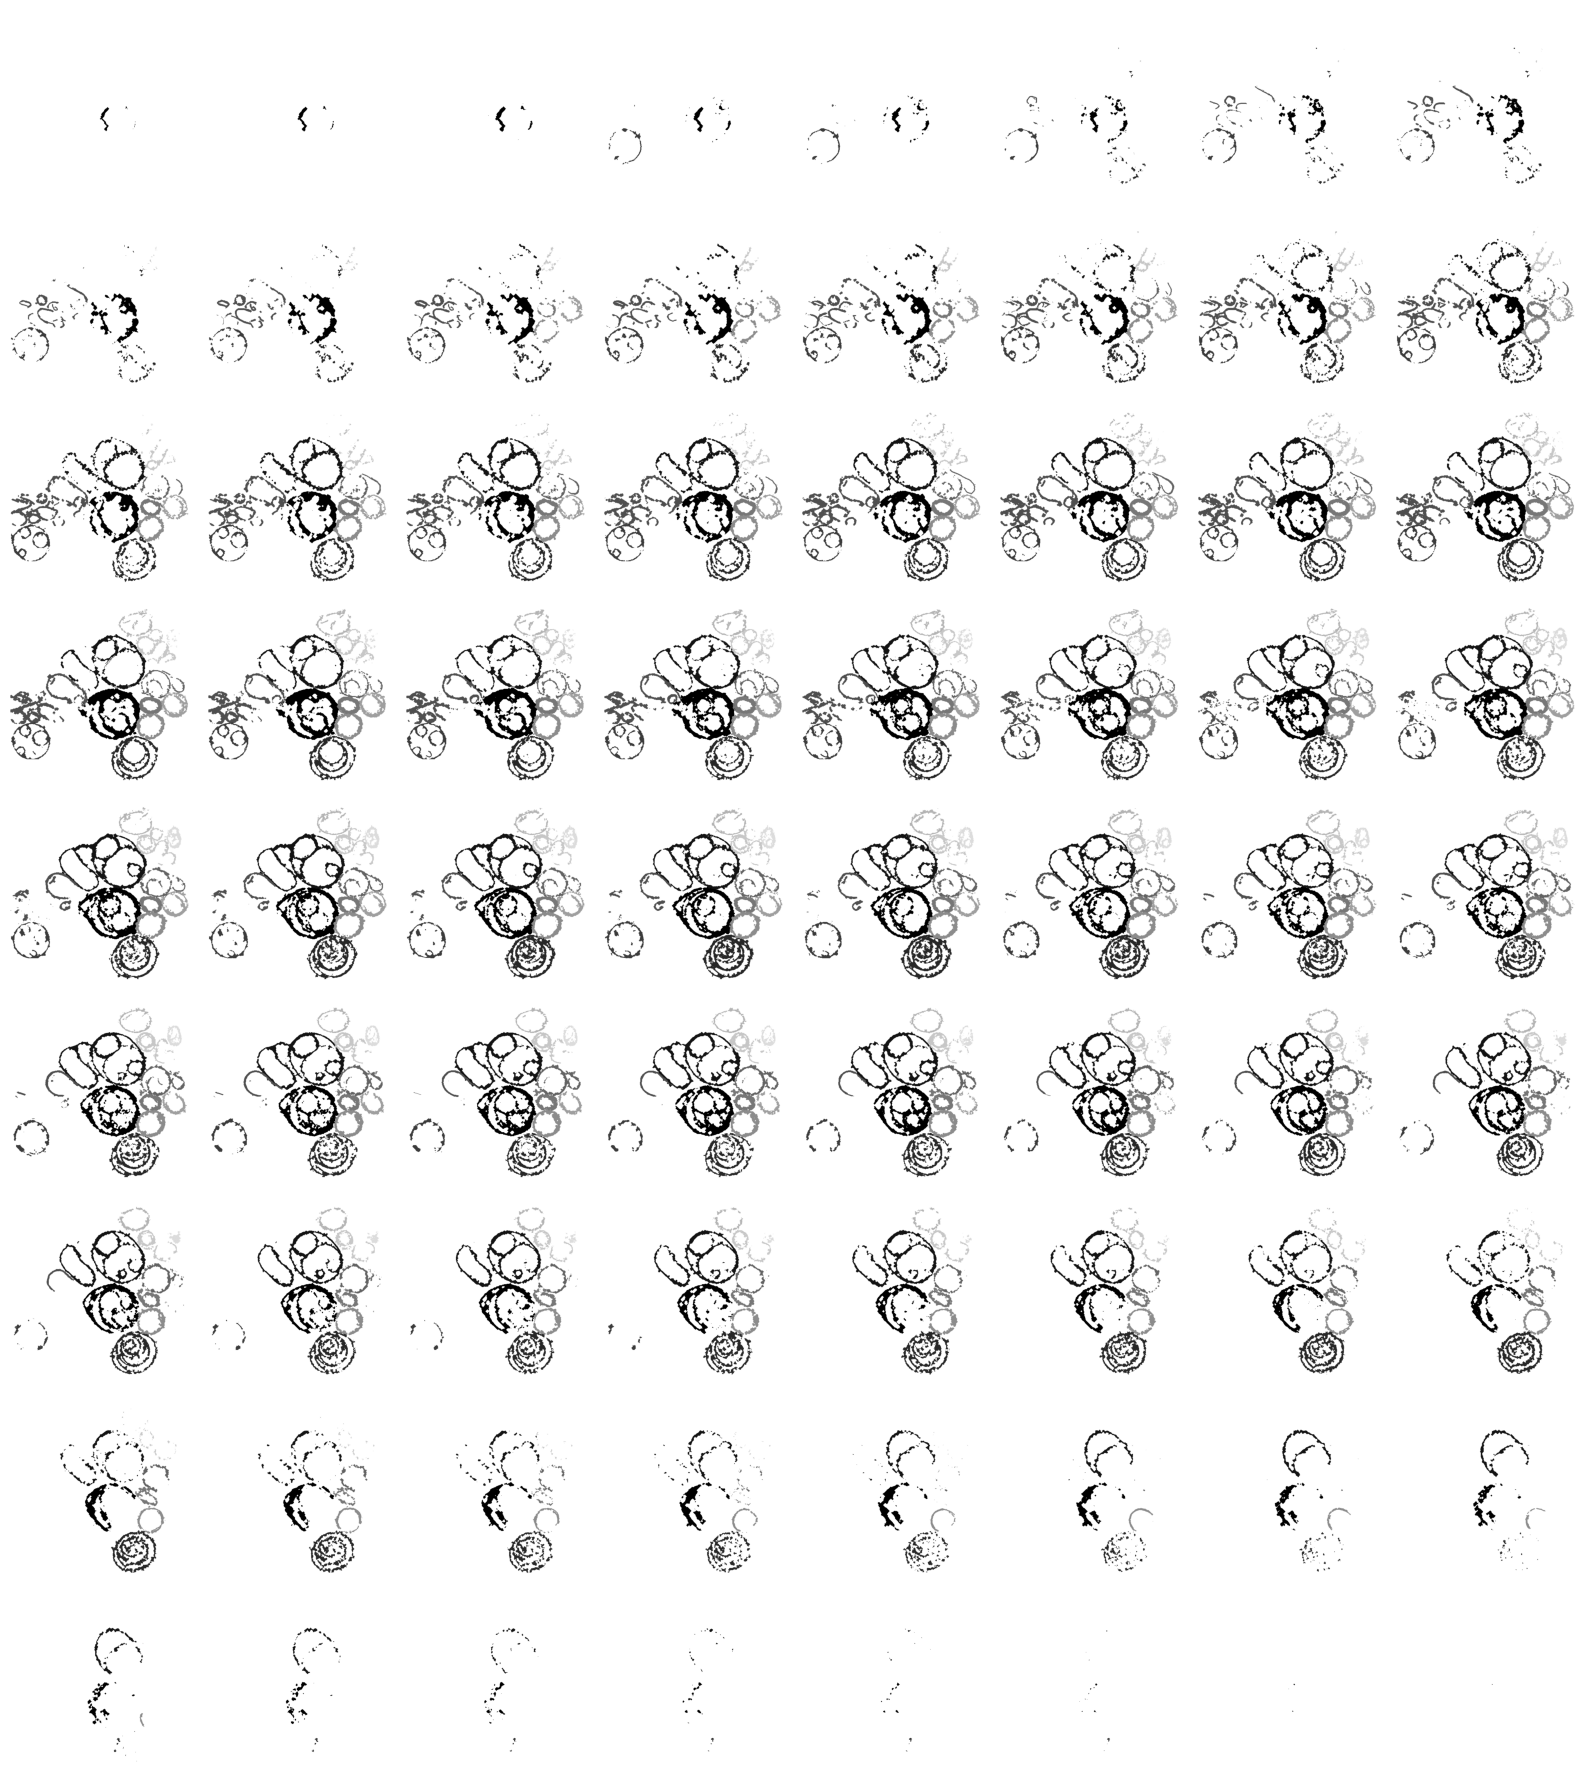

In [4]:
# Plot only the informative (remaining) slices
n_slices_filtered = volume_filtered.shape[0]
n_cols = 8
n_rows = int(np.ceil(n_slices_filtered / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for i in range(n_rows * n_cols):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]
    if i < n_slices_filtered:
        ax.imshow(volume_filtered[i], cmap="gray")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh

# --- 1) Build foreground token matrix using ONLY masked features ---
X = masked_features.astype(np.float32)
num_tokens_fg = X.shape[0]
if num_tokens_fg < 2:
    raise ValueError("Not enough foreground tokens for normalized cut.")

# L2 normalize token descriptors
X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
print(f"Foreground tokens used for Ncut: {num_tokens_fg}")

# --- 2) Full affinity matrix W (NO downsampling, NO k-NN) ---
tau = 0.0
eps_graph = 1e-5
no_binary_graph = False

A = X @ X.T  # cosine similarity because X is normalized

if no_binary_graph:
    A[A < tau] = 0.0
else:
    A = (A > tau).astype(np.float32)

# Symmetrize and keep self-links
A = np.maximum(A, A.T)
np.fill_diagonal(A, 1.0)

W = csr_matrix(A)
del A

# --- 3) Normalized Cut (2-way) with generalized eigenproblem ---
deg = np.asarray(W.sum(axis=1)).ravel() + eps_graph
D = diags(deg)
L = D - W

_, eigvecs = eigsh(L, k=2, M=D, which="SM")
second_smallest_vec = eigvecs[:, 1]

avg = float(second_smallest_vec.mean())
labels_fg = second_smallest_vec > avg
seed = int(np.argmax(np.abs(second_smallest_vec)))

if not labels_fg[seed]:
    second_smallest_vec = -second_smallest_vec
    labels_fg = np.logical_not(labels_fg)

labels_fg = labels_fg.astype(np.int8)

# Token labels on patch grid (-1 for background), fill foreground by flat_mask order
token_labels_flat = -np.ones(flat_mask.shape[0], dtype=np.int8)
token_labels_flat[flat_mask] = labels_fg
token_labels = token_labels_flat.reshape(patch_mask.shape)

# --- 4) Upscale token labels to voxel resolution ---
token_labels_t = torch.from_numpy(token_labels.astype(np.float32))[None, None]  # [1,1,S,p_h,p_w]
partition_up = F.interpolate(
    token_labels_t,
    size=volume_filtered.shape,
    mode="nearest",
).squeeze(0).squeeze(0).numpy().astype(np.int8)

partition_up[volume_binary == 0] = -1

print(f"Token partition labels shape: {token_labels.shape}")
print(f"Upscaled partition volume shape: {partition_up.shape}")
print(f"Partition counts (fg only): {(partition_up == 0).sum()} / {(partition_up == 1).sum()}")

# --- 5) Same volume representation, colored by partition ---
mask_part = partition_up >= 0
zf, y, x = np.where(mask_part)
z = valid_indices[zf]
part_vals = partition_up[mask_part]

# Two distinct colors for the two partitions
partition_colors = np.array([
    [0.10, 0.45, 1.00],
    [1.00, 0.35, 0.15],
], dtype=np.float32)
rgb_vals = partition_colors[part_vals]

xc = (x.min() + x.max()) / 2.0
yc = (y.min() + y.max()) / 2.0
zc = (z.min() + z.max()) / 2.0

xx = x - xc
yy = y - yc
zz = z - zc

views = [
    ("(0,0,0)", 0, 0, 0),
    ("(30,0,0)", 30, 0, 0),
    ("(-30,0,0)", -30, 0, 0),
    ("(0,30,0)", 0, 30, 0),
    ("(0,-30,0)", 0, -30, 0),
    ("(0,0,45)", 0, 0, 45),
    ("(25,25,0)", 25, 25, 0),
    ("(25,0,45)", 25, 0, 45),
    ("(0,25,45)", 0, 25, 45),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15), facecolor="white")
axs = axs.ravel()

for i, (title, ax_deg, ay_deg, az_deg) in enumerate(views):
    axr = np.deg2rad(ax_deg)
    ayr = np.deg2rad(ay_deg)
    azr = np.deg2rad(az_deg)

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(axr), -np.sin(axr)],
        [0, np.sin(axr), np.cos(axr)],
    ])
    Ry = np.array([
        [np.cos(ayr), 0, np.sin(ayr)],
        [0, 1, 0],
        [-np.sin(ayr), 0, np.cos(ayr)],
    ])
    Rz = np.array([
        [np.cos(azr), -np.sin(azr), 0],
        [np.sin(azr), np.cos(azr), 0],
        [0, 0, 1],
    ])

    R = Rz @ Ry @ Rx
    rot = R @ np.vstack((xx, yy, zz))

    u = rot[0]
    v = rot[1]

    axs[i].scatter(u, v, c=rgb_vals, s=1, linewidths=0, alpha=0.95)
    axs[i].set_aspect("equal")
    axs[i].axis("off")
    axs[i].set_title(title)
    axs[i].set_facecolor("white")

plt.tight_layout()
plt.show()

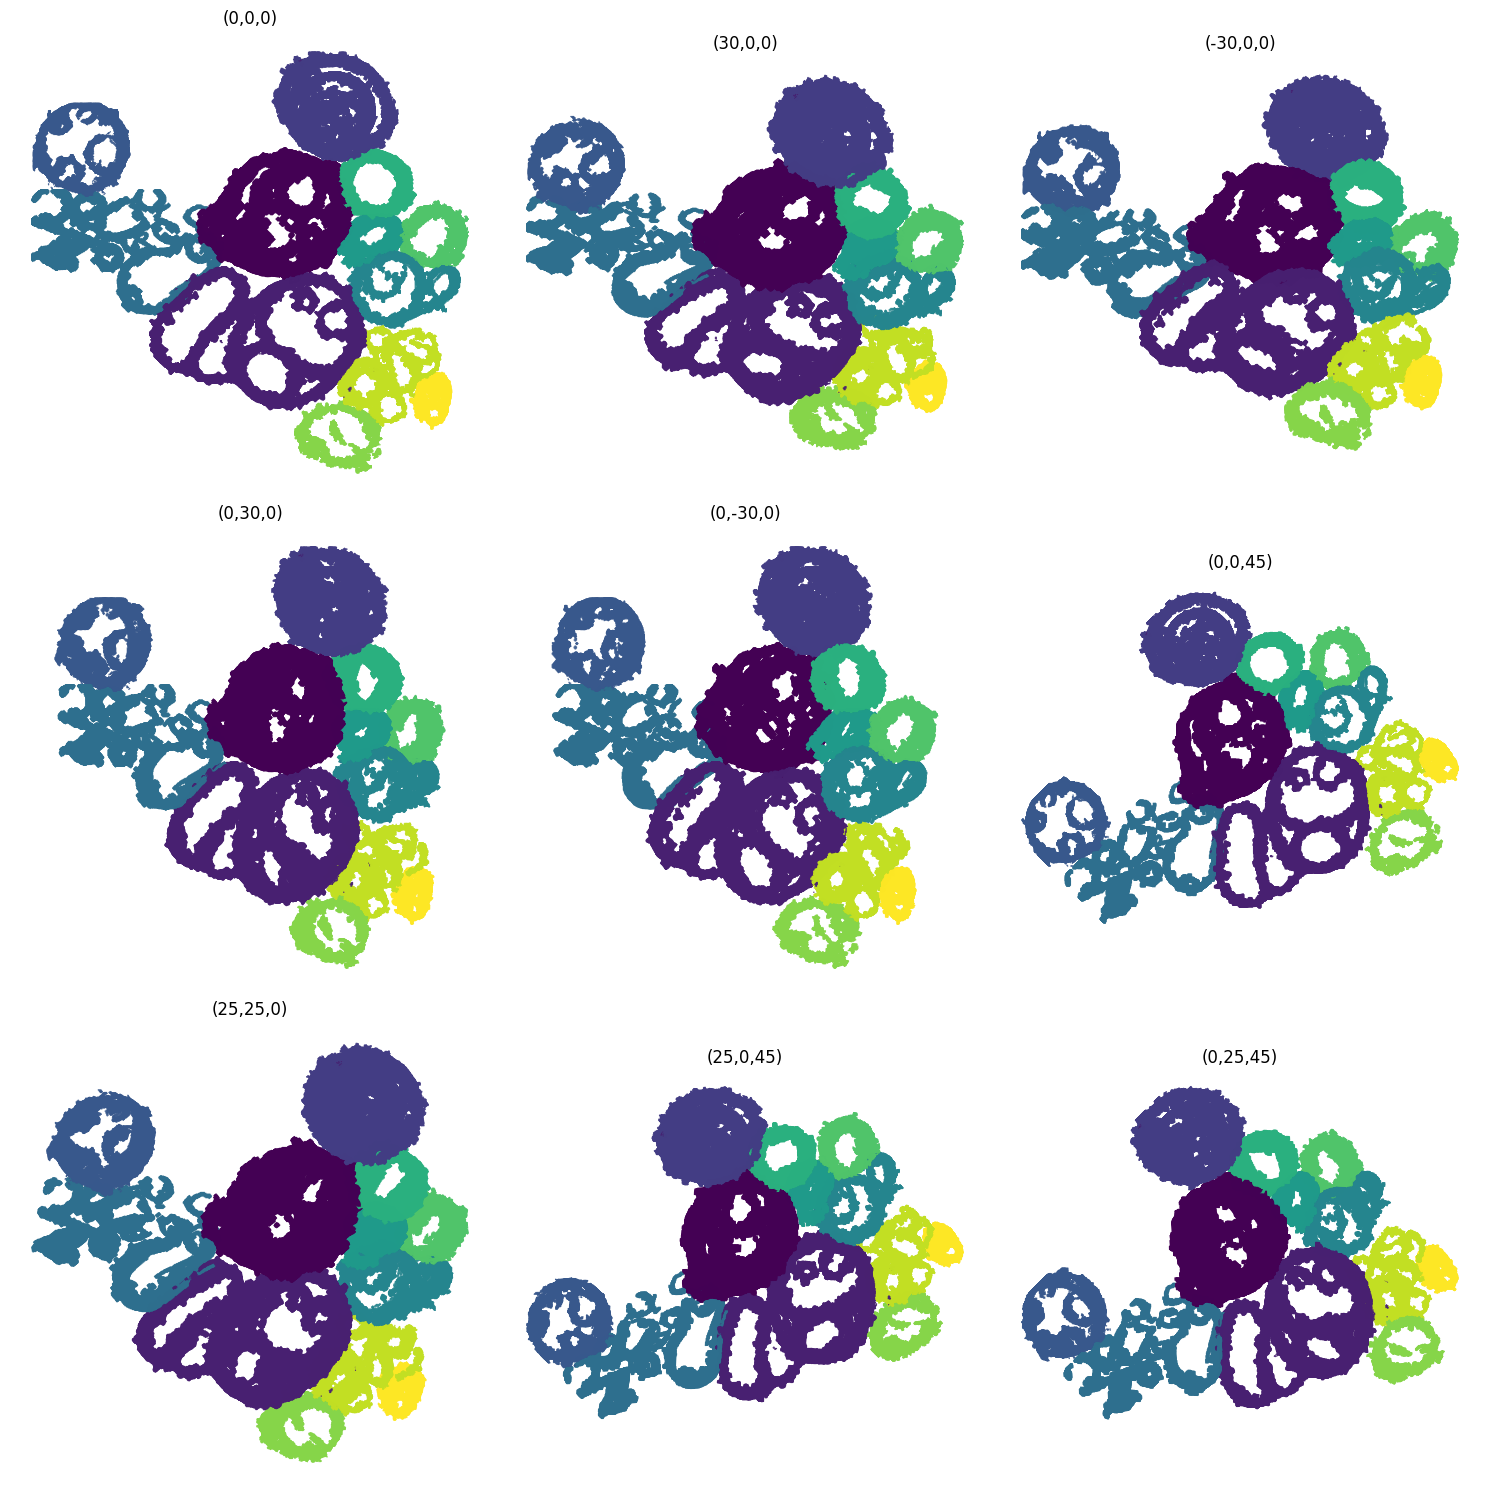

In [5]:
# Use all informative slices directly
vol = volume_filtered.astype(np.float32)

# Background is the constant max value (1.0 here)
bg = vol.max()
eps = 1e-6
mask = vol < (bg - eps)

# Coordinates in filtered volume
zf, y, x = np.where(mask)
vals = vol[mask]

# Map filtered z back to original z-space
z = valid_indices[zf]

# Center coordinates for stable rotations
xc = (x.min() + x.max()) / 2.0
yc = (y.min() + y.max()) / 2.0
zc = (z.min() + z.max()) / 2.0

xx = x - xc
yy = y - yc
zz = z - zc

# 9 viewpoints: (rotX, rotY, rotZ) in degrees
views = [
    ("(0,0,0)", 0, 0, 0),
    ("(30,0,0)", 30, 0, 0),
    ("(-30,0,0)", -30, 0, 0),
    ("(0,30,0)", 0, 30, 0),
    ("(0,-30,0)", 0, -30, 0),
    ("(0,0,45)", 0, 0, 45),
    ("(25,25,0)", 25, 25, 0),
    ("(25,0,45)", 25, 0, 45),
    ("(0,25,45)", 0, 25, 45),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))
axs = axs.ravel()

for i, (title, ax_deg, ay_deg, az_deg) in enumerate(views):
    axr = np.deg2rad(ax_deg)
    ayr = np.deg2rad(ay_deg)
    azr = np.deg2rad(az_deg)

    # Rotation matrices
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(axr), -np.sin(axr)],
        [0, np.sin(axr),  np.cos(axr)],
    ])
    Ry = np.array([
        [ np.cos(ayr), 0, np.sin(ayr)],
        [0, 1, 0],
        [-np.sin(ayr), 0, np.cos(ayr)],
    ])
    Rz = np.array([
        [np.cos(azr), -np.sin(azr), 0],
        [np.sin(azr),  np.cos(azr), 0],
        [0, 0, 1],
    ])

    # Combined rotation: X -> Y -> Z
    R = Rz @ Ry @ Rx
    rot = R @ np.vstack((xx, yy, zz))

    # Orthographic projection to 2D
    u = rot[0]
    v = rot[1]

    axs[i].scatter(u, v, c=vals, s=1, cmap="viridis", linewidths=0, alpha=0.9)
    axs[i].set_aspect("equal")
    axs[i].axis("off")
    axs[i].set_title(title)

plt.tight_layout()
plt.show()